# Jets with FastJet's array-oriented interface (awkward)

The companion of `jet_fastjet.ipynb`, written with the **array-oriented interface** of the FastJet Python
package (scikit-hep `fastjet`): the hadrons of *all* events are one jagged awkward array
(`events * var * Momentum4D`), one `fastjet.ClusterSequence(array, jetdef)` call clusters every event in C++,
and jets, constituents and substructure come back as awkward arrays. No Python loop over events or
particles.

**What the array interface supports**, and where this notebook uses it:

| array-oriented call | section |
|---|---|
| `ClusterSequence(events, JetDefinition(...))` on a jagged `Momentum4D` array | all |
| `inclusive_jets(min_pt)`, `constituents(min_pt)`, `constituent_index(min_pt)` | 2, 5, 6 |
| `n_particles()`, `unclustered_particles()` | 2 |
| `exclusive_jets(n_jets=...)`, `exclusive_jets(dcut=...)`, `exclusive_jets_ycut`, `exclusive_dmerge(_max)`, `exclusive_ymerge(_max)`, `n_exclusive_jets(dcut)` | 3 |
| `exclusive_jets_softdrop_grooming`, `exclusive_jets_lund_declusterings`, `exclusive_jets_energy_correlator`, `njettiness` (fastjet-contrib) | 4 |

**What it does not support:** jet areas (`ClusterSequenceArea`, `AreaDefinition`, ghosts), background
estimation (`JetMedianBackgroundEstimator`, `GridMedianBackgroundEstimator`), `Subtractor`, `Selector`s and
`PseudoJet.user_index`. Those exist only in the classic (SWIG, `list` of `PseudoJet`) interface that
`jet_fastjet.ipynb` uses. Section 6 shows the workaround for areas: the notebook adds FastJet's explicit
ghosts itself, as extra particles of the awkward array, and counts them in each jet. That reproduces
`active_area_explicit_ghosts`, but it is this notebook's code, not a FastJet feature.
`constituent_index` stands in for `user_index`: it points back into the input array, so every field of a
constituent (pid, origin, ...) is at hand.

**Events** (as in `jet_fastjet.ipynb`): **jet** = `jet_frag` samples alone; **bkg** = `bulk_bg` sample $k$;
**bkg+jet** = `bulk_bg` sample $k$ + `jet_frag` sample $k \bmod n_\mathrm{frag}$ (embedding);
**bkg+wake+jet** = `bulk_jet` sample $k$ + the same `jet_frag` sample (the full event). Same cuts: charged
hadrons (`PARTICLES=full` for all), $|\eta| < 1.5$, $p_T > 0.15$ GeV, massless; anti-$k_T$ $R = 0.4$, jets
$|\eta| < 1.1$; $\rho$ from $k_T$ $R = 0.4$ jets without the two hardest.

    HADRON_DIR=/path/to/out MAX_EVENTS=200 MAX_OVERSAMPLES=100 jupyter nbconvert --to notebook --execute jet_fastjet_awkward.ipynb

In [1]:
%matplotlib inline
import os
import sys
import time
import warnings
try:  # registers Blosc, the default compression of the hadron files
    import hdf5plugin  # noqa: F401
except ImportError:
    print("note: pip install hdf5plugin -- needed for Blosc-compressed files (lzf files read without it)")
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import vector
import fastjet

vector.register_awkward()      # Momentum4D records get .pt, .eta, .phi, .deltaR, ...
# fastjet warns on every exclusive call because it compares the JetDefinition, not its algorithm,
# with kt/C-A: spurious for the kt and C/A clusterings used here
warnings.filterwarnings("ignore", message="dcut and exclusive jets for jet-finders other than kt")

sys.path.insert(0, os.path.join("..", "..", "python"))
from jetscape.hadrons_h5 import CHARGED, HadronFile, HadronFileReader

# --- inputs ---------------------------------------------------------------------------------
HADRON_DIR = os.environ.get("HADRON_DIR", os.path.join("..", "prod_AuAu_0_10_jet", "out"))
MAX_EVENTS = int(os.environ.get("MAX_EVENTS", "0")) or None            # None: every event
MAX_OVERSAMPLES = int(os.environ.get("MAX_OVERSAMPLES", "0")) or None  # per event; None: all
PARTICLES = os.environ.get("PARTICLES", "charged")   # 'charged' or 'full'

# --- jet finding (as jet_fastjet.ipynb) -------------------------------------------------------
R = 0.4
R_BKG = 0.4
ETA_MAX = 1.5
PT_MIN_PART = 0.15
JET_ETA = ETA_MAX - R
BKG_ETA = ETA_MAX - R_BKG
N_EXCL = 2
GHOST_AREA = 0.005
JET_PT_MIN_FRAG = 10.0
FF_PT_BINS = [(10, 20), (20, 30), (30, 60)]
SUB_PT_MIN = 20.0          # GeV, jets for the substructure of section 4
CHUNK = 250                # samples per clustering call with ghosts (memory)
RNG = np.random.default_rng(2026)

JET_DEF = fastjet.JetDefinition(fastjet.antikt_algorithm, R)
BKG_DEF = fastjet.JetDefinition(fastjet.kt_algorithm, R_BKG)

COL = {"jet": "#2a78d6", "bkg": "#eb6834", "bkg+wake+jet": "#1baf7a", "bkg+jet": "#4a3aa7"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "lines.linewidth": 2, "figure.dpi": 110,
                     "legend.frameon": False})
print(f"fastjet {fastjet.__version__}, awkward {ak.__version__}, vector {vector.__version__}")

fastjet 3.5.1.5, awkward 2.8.11, vector 1.9.0


## 1. The hadron files as awkward arrays

`unit_events` reads all samples of one unit (an event's `bulk_jet` or `jet_frag`, or a background) with one
HDF5 slice and cuts it into samples with `ak.unflatten` along `sample_offsets`. The records are
`Momentum4D` (massless: $E = |\vec p|$), plus `pid`, `charged` and `origin` (0 bulk, 1 jet hadron, -1
ghost). The cuts are one boolean mask on the jagged array. `ak.to_packed` makes the contiguous
`ListOffsetArray` that `ClusterSequence` takes as a batch of events.

In [2]:
CHARGED_PID = np.array(CHARGED)


def unit_events(path, unit, origin, max_samples=None):
    # the samples of one recorded unit as an awkward array: samples * var * Momentum4D
    with HadronFile(path) as hf:
        u = hf.unit_index(unit)
        s0, s1 = int(hf.unit_offsets[u]), int(hf.unit_offsets[u + 1])
        if max_samples:
            s1 = min(s1, s0 + max_samples)
        so = hf.sample_offsets[s0:s1 + 1]
        a, b = int(so[0]), int(so[-1])
        g = hf.f["hadrons"]
        p = g["p"][a:b].astype(np.float64)
        pid = g["pid"][a:b]
    rec = ak.zip({"px": p[:, 1], "py": p[:, 2], "pz": p[:, 3], "E": np.sqrt((p[:, 1:] ** 2).sum(axis=1)),
                  "pid": pid, "charged": np.isin(np.abs(pid), CHARGED_PID),
                  "origin": np.full(b - a, origin, dtype=np.int8)}, with_name="Momentum4D")
    return ak.unflatten(rec, np.diff(so))


def accept(ev):
    m = (abs(ev.eta) < ETA_MAX) & (ev.pt > PT_MIN_PART)
    if PARTICLES == "charged":
        m = m & ev.charged
    return ak.to_packed(ev[m])


def gather(parts, idx):
    # parts[event][idx[event][jet][i]] for all events at once: events * jets * constituents
    off = np.cumsum(np.r_[0, ak.num(parts)[:-1].to_numpy()])
    flat = ak.flatten(parts)[ak.flatten(idx + off, axis=None)]
    return ak.unflatten(ak.unflatten(flat, ak.flatten(ak.num(idx, axis=2))), ak.num(idx, axis=1))


def sorted_jets(cs, min_pt=0.0):
    # inclusive jets and their constituent indices, sorted by pT (inclusive_jets is not)
    jets, idx = cs.inclusive_jets(min_pt=min_pt), cs.constituent_index(min_pt=min_pt)
    order = ak.argsort(jets.pt, axis=1, ascending=False)
    return jets[order], idx[order]


t0 = time.time()
reader = HadronFileReader(HADRON_DIR)
EVENTS = [int(e) for e in reader.events(slice(0, MAX_EVENTS))
          if reader.n_frag(e) > 0 and reader.n_oversamples(e) > 0 and reader.n_samples("bulk_bg", e) > 0]
frag_l, bkg_l, bulkjet_l = [], [], []
FRAG_EVENT, AU_EVENT, AU_FRAG = [], [], []    # per sample: event; per AuAu sample: its jet_frag sample
frag_first = 0
for e in EVENTS:
    info = reader.event_info(e)
    n_over = min(reader.n_oversamples(e), reader.n_samples("bulk_bg", e), MAX_OVERSAMPLES or 10 ** 9)
    fr = accept(unit_events(f"{info.stem}_hadrons_jet_frag.h5", info.local_event, 1))
    frag_l.append(fr)
    bkg_l.append(accept(unit_events(f"{info.stem}_hadrons_bulk_bg.h5", info.bg_unit, 0, n_over)))
    bulkjet_l.append(accept(unit_events(f"{info.stem}_hadrons_bulk_jet.h5", info.local_event, 0, n_over)))
    FRAG_EVENT += [e] * len(fr)
    AU_EVENT += [e] * n_over
    AU_FRAG += list(frag_first + np.arange(n_over) % len(fr))    # index into FRAG
    frag_first += len(fr)
FRAG = ak.to_packed(ak.concatenate(frag_l))
FRAG_EVENT, AU_EVENT, AU_FRAG = np.array(FRAG_EVENT), np.array(AU_EVENT), np.array(AU_FRAG)
LEGS_REAL = {"bkg": ak.to_packed(ak.concatenate(bkg_l))}
LEGS_REAL["bkg+jet"] = ak.to_packed(ak.concatenate([LEGS_REAL["bkg"], FRAG[AU_FRAG]], axis=1))
LEGS_REAL["bkg+wake+jet"] = ak.to_packed(ak.concatenate([ak.concatenate(bulkjet_l), FRAG[AU_FRAG]], axis=1))
del frag_l, bkg_l, bulkjet_l
LEGS = tuple(LEGS_REAL)
N_FRAG = {e: int((FRAG_EVENT == e).sum()) for e in EVENTS}
N_OVER = {e: int((AU_EVENT == e).sum()) for e in EVENTS}
print(f"{len(EVENTS)} event(s) read in {time.time() - t0:.1f} s")
print(f"FRAG: {FRAG.type}  ({ak.mean(ak.num(FRAG)):.1f} particles per sample)")
for leg, arr in LEGS_REAL.items():
    print(f"{leg:13s}: {len(arr)} samples, {ak.mean(ak.num(arr)):.0f} particles per sample, "
          f"{arr.nbytes / 2**20:.0f} MB")

2 event(s) read in 1.4 s
FRAG: 100 * var * Momentum4D[px: float64, py: float64, pz: float64, E: float64, pid: int32, charged: bool, origin: int8]  (15.6 particles per sample)
bkg          : 1000 samples, 1979 particles per sample, 72 MB
bkg+jet      : 1000 samples, 1994 particles per sample, 72 MB
bkg+wake+jet : 1000 samples, 2004 particles per sample, 73 MB


In [3]:
def per_sample_hist(values, event_of, bins, n_samples):
    # event average of per-sample-mean histograms, and the sampling error
    values, event_of = np.asarray(values), np.asarray(event_of)
    h, v = np.zeros(len(bins) - 1), np.zeros(len(bins) - 1)
    for e in n_samples:
        c = np.histogram(values[event_of == e], bins)[0]
        h += c / n_samples[e]
        v += c / n_samples[e] ** 2
    return h / len(n_samples), np.sqrt(v) / len(n_samples)


def step(ax, bins, h, err, label, color, ls="-"):
    c, d = 0.5 * (bins[1:] + bins[:-1]), np.diff(bins)
    ax.stairs(h / d, bins, color=color, ls=ls, lw=2, label=label)
    ax.errorbar(c, h / d, err / d, fmt="none", ecolor=color, elinewidth=1, alpha=0.8)


def per_jet(event_level, jets):
    # an array with one value per sample, broadcast to one per jet and flattened
    return ak.flatten(ak.broadcast_arrays(ak.Array(event_level), jets.pt)[0]).to_numpy()

## 2. Jets of the jet hadrons alone: spectrum and fragmentation function

One `ClusterSequence` call for all `jet_frag` samples. The fragmentation variable
$z = \vec p_h\cdot\vec p_\mathrm{jet}/|\vec p_\mathrm{jet}|^2$ is computed by broadcasting the jets
(`samples * jets`) against their constituents (`samples * jets * constituents`). The last cell of the
section clusters the same samples with the classic interface, one `PseudoJet` list at a time: the jets must
be identical.

#--------------------------------------------------------------------------
#                         FastJet release 3.5.1
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           https://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------
100 samples clustered in 11 ms: 173 jets (pT > 10.0 GeV, |eta| < 1.1)


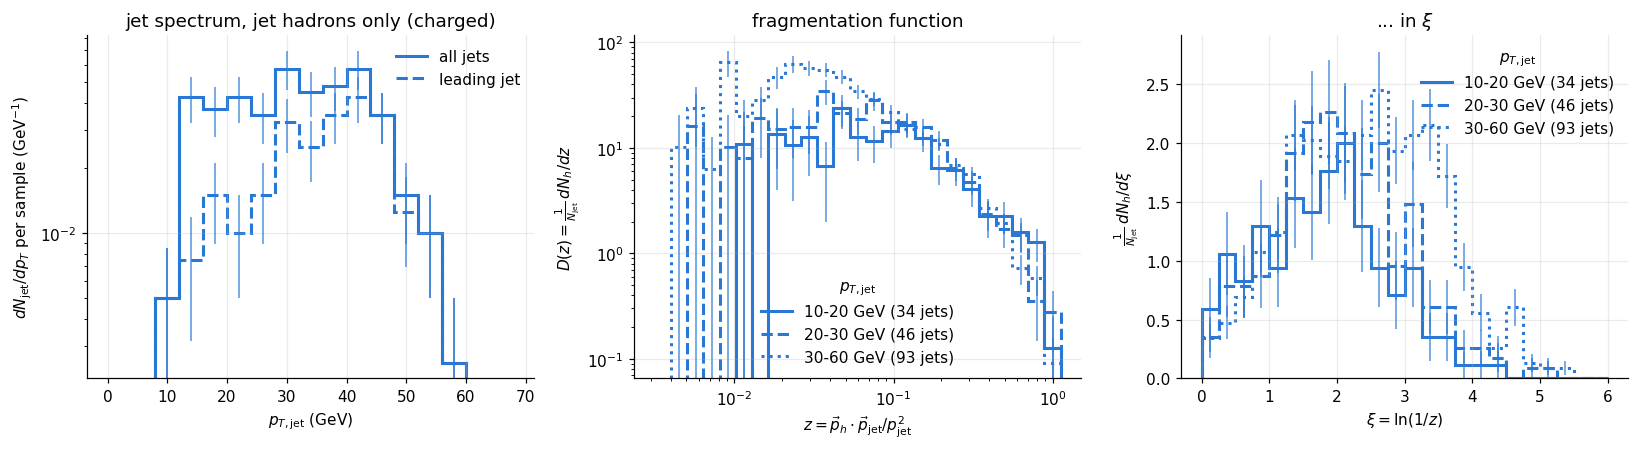

In [4]:
t0 = time.time()
cs_frag = fastjet.ClusterSequence(FRAG, JET_DEF)
FJ, FJ_IDX = sorted_jets(cs_frag, JET_PT_MIN_FRAG)
keep = abs(FJ.rapidity) < JET_ETA        # as SelectorAbsRapMax
FJ, FJ_IDX = FJ[keep], FJ_IDX[keep]
FJ_CONS = gather(FRAG, FJ_IDX)
t_frag = time.time() - t0
z = (FJ_CONS.px * FJ.px + FJ_CONS.py * FJ.py + FJ_CONS.pz * FJ.pz) / (FJ.px ** 2 + FJ.py ** 2 + FJ.pz ** 2)
print(f"{len(FRAG)} samples clustered in {t_frag * 1e3:.0f} ms: {ak.sum(ak.num(FJ))} jets "
      f"(pT > {JET_PT_MIN_FRAG} GeV, |eta| < {JET_ETA:.1f})")
print("n_particles() of the first samples:", cs_frag.n_particles()[:5].tolist(),
      "  unclustered (anti-kT: none):", int(ak.sum(ak.num(cs_frag.unclustered_particles()))))
print("jets of sample 0:", [f"pT {j.pt:.1f} eta {j.eta:+.2f} phi {j.phi:+.2f}" for j in FJ[0]])

fj_pt, fj_ev = ak.flatten(FJ.pt).to_numpy(), per_jet(FRAG_EVENT, FJ)
PT_BINS = np.arange(0, 72, 4.0)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
h, err = per_sample_hist(fj_pt, fj_ev, PT_BINS, N_FRAG)
step(axs[0], PT_BINS, h, err, "all jets", COL["jet"])
h, err = per_sample_hist(ak.firsts(FJ.pt).to_numpy(), FRAG_EVENT, PT_BINS, N_FRAG)
step(axs[0], PT_BINS, np.nan_to_num(h), np.nan_to_num(err), "leading jet", COL["jet"], ls="--")
axs[0].set(xlabel=r"$p_{T,\mathrm{jet}}$ (GeV)", ylabel=r"$dN_\mathrm{jet}/dp_T$ per sample (GeV$^{-1}$)",
           yscale="log", title=f"jet spectrum, jet hadrons only ({PARTICLES})")
axs[0].legend()
Z_BINS, XI_BINS = np.logspace(-2.5, 0.05, 26), np.linspace(0, 6, 25)
jpt_c = ak.broadcast_arrays(FJ.pt, z)[0]
for (lo, hi), ls in zip(FF_PT_BINS, ["-", "--", ":"]):
    nj = int(((fj_pt >= lo) & (fj_pt < hi)).sum())
    zz = ak.flatten(z[(jpt_c >= lo) & (jpt_c < hi)], axis=None).to_numpy()
    if nj == 0:
        continue
    for ax, x, b in ((axs[1], zz, Z_BINS), (axs[2], np.log(1 / zz), XI_BINS)):
        c = np.histogram(x, b)[0]
        step(ax, b, c / nj, np.sqrt(c) / nj, f"{lo}-{hi} GeV ({nj} jets)", COL["jet"], ls=ls)
axs[1].set(xscale="log", yscale="log", xlabel=r"$z = \vec p_h\cdot\vec p_\mathrm{jet}/p_\mathrm{jet}^2$",
           ylabel=r"$D(z) = \frac{1}{N_\mathrm{jet}}\,dN_h/dz$", title="fragmentation function")
axs[2].set(xlabel=r"$\xi = \ln(1/z)$", ylabel=r"$\frac{1}{N_\mathrm{jet}}\,dN_h/d\xi$", title="... in $\\xi$")
axs[1].legend(title=r"$p_{T,\mathrm{jet}}$"); axs[2].legend(title=r"$p_{T,\mathrm{jet}}$")
plt.tight_layout(); plt.show()

In [5]:
# the same jets with the classic interface, one PseudoJet list per sample
t0 = time.time()
diff, n_cl = 0.0, 0
for i in range(len(FRAG)):
    ev = FRAG[i]
    parts = [fastjet.PseudoJet(float(px), float(py), float(pz), float(E))
             for px, py, pz, E in zip(ev.px, ev.py, ev.pz, ev.E)]
    cl = fastjet.ClusterSequence(parts, JET_DEF)
    pts = sorted((j.pt() for j in cl.inclusive_jets(JET_PT_MIN_FRAG) if abs(j.rap()) < JET_ETA), reverse=True)
    ref = FJ.pt[i].to_list()
    assert len(pts) == len(ref), (i, pts, ref)
    diff = max([diff] + [abs(a - b) for a, b in zip(pts, ref)])
    n_cl += len(pts)
print(f"classic interface: {n_cl} jets in {time.time() - t0:.2f} s, max |pT(classic) - pT(array)| = {diff:.2e} GeV")

classic interface: 173 jets in 0.11 s, max |pT(classic) - pT(array)| = 7.11e-15 GeV


## 3. Exclusive clustering and the merging scales

Exclusive jets need an algorithm whose history is ordered in a distance: $k_T$ here, on the jet hadrons
alone. `exclusive_jets(n_jets=2)` forces each sample into two jets, i.e. the dijet axes, which should sit on
the two shower initiators; `exclusive_dmerge(njets=2)` is the $d_{ij}$ of the merging that took the
event from 3 jets to 2 ($\sqrt{d}$ is a $k_T$ in GeV); `n_exclusive_jets(dcut)` counts the jets resolved
at a scale, the inverse of `exclusive_jets(dcut=...)`.

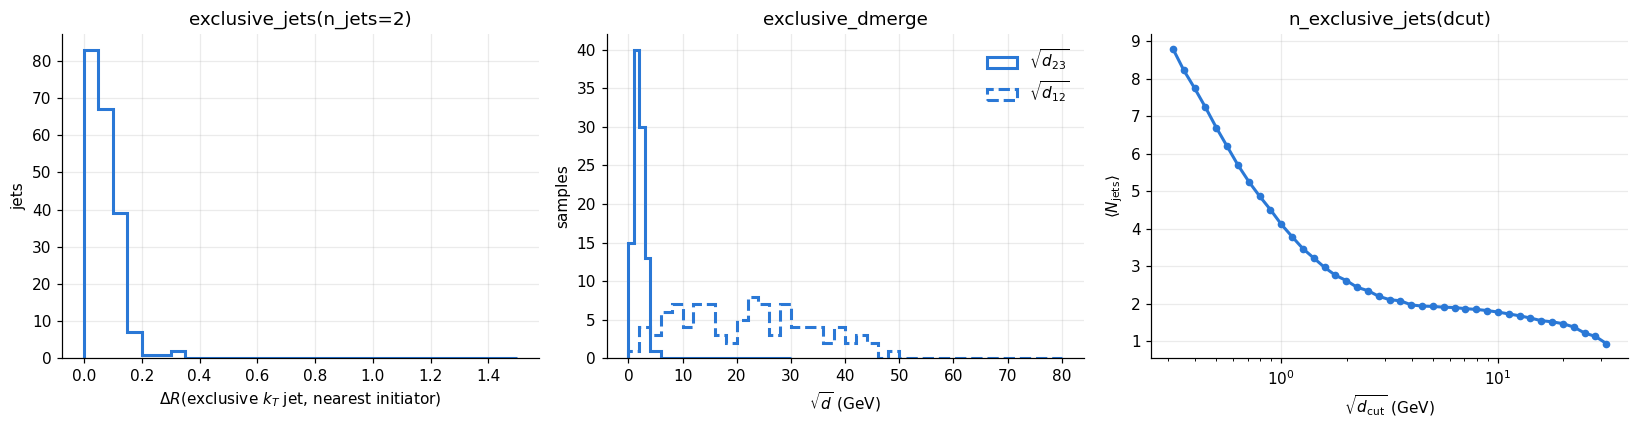

exclusive dijet axes within 0.2 of an initiator: 98%; <sqrt(d23)> = 2.0 GeV
exclusive_jets(dcut=25) of sample 0: ['22.9', '42.1'] | ycut 0.01: ['22.9', '42.1']


In [6]:
cs_kt = fastjet.ClusterSequence(FRAG, fastjet.JetDefinition(fastjet.kt_algorithm, 1.0))
ex2 = cs_kt.exclusive_jets(n_jets=2)
d23 = cs_kt.exclusive_dmerge(njets=2).to_numpy()
d12 = cs_kt.exclusive_dmerge(njets=1).to_numpy()
# the initiators of each sample's event, as Momentum4D
ini = {e: reader.event_info(e).initiators() for e in EVENTS}
ini_arr = ak.Array([[{"px": r[3], "py": r[4], "pz": r[5], "E": r[6]} for r in ini[e]] for e in FRAG_EVENT],
                   with_name="Momentum4D")
ini2 = ini_arr[ak.argsort(ini_arr.pt, axis=1, ascending=False)][:, :2]
pairs = ak.cartesian({"j": ex2, "i": ini2}, nested=True)
dr_min = ak.min(pairs.j.deltaR(pairs.i), axis=2)          # each exclusive jet to its nearest initiator
dcuts = np.logspace(-1, 3, 41)
n_ex = np.array([ak.mean(cs_kt.n_exclusive_jets(dcut=d)) for d in dcuts])

fig, axs = plt.subplots(1, 3, figsize=(15, 4.0))
axs[0].hist(ak.flatten(dr_min).to_numpy(), np.linspace(0, 1.5, 31), histtype="step", lw=2, color=COL["jet"])
axs[0].set(xlabel=r"$\Delta R$(exclusive $k_T$ jet, nearest initiator)", ylabel="jets",
           title="exclusive_jets(n_jets=2)")
b = np.linspace(0, 30, 31)
axs[1].hist(np.sqrt(d23), b, histtype="step", lw=2, color=COL["jet"], label=r"$\sqrt{d_{23}}$")
axs[1].hist(np.sqrt(d12), np.linspace(0, 80, 41), histtype="step", lw=2, ls="--", color=COL["jet"],
            label=r"$\sqrt{d_{12}}$")
axs[1].set(xlabel=r"$\sqrt{d}$ (GeV)", ylabel="samples", title="exclusive_dmerge")
axs[1].legend()
axs[2].plot(np.sqrt(dcuts), n_ex, color=COL["jet"], marker="o", ms=4)
axs[2].set(xscale="log", xlabel=r"$\sqrt{d_\mathrm{cut}}$ (GeV)", ylabel=r"$\langle N_\mathrm{jets}\rangle$",
           title="n_exclusive_jets(dcut)")
plt.tight_layout(); plt.show()
print(f"exclusive dijet axes within 0.2 of an initiator: {np.mean(ak.flatten(dr_min).to_numpy() < 0.2):.0%}; "
      f"<sqrt(d23)> = {np.sqrt(d23).mean():.1f} GeV")
print("exclusive_jets(dcut=25) of sample 0:", [f"{p:.1f}" for p in cs_kt.exclusive_jets(dcut=25.0)[0].pt],
      "| ycut 0.01:", [f"{p:.1f}" for p in cs_kt.exclusive_jets_ycut(ycut=0.01)[0].pt])

## 4. Substructure: softdrop, Lund plane, energy correlators, N-subjettiness

These calls of the array interface (fastjet-contrib RecursiveTools, LundPlane, EnergyCorrelator,
Nsubjettiness) act on the *exclusive* jets of each entry of the input. To groom each anti-$k_T$ jet, the
jets' constituents become the entries: `ak.flatten(constituents, axis=1)` gives `jets * constituents`,
re-clustered with Cambridge/Aachen and asked for one exclusive jet, which is the whole jet with its C/A
history.

* softdrop ($z_\mathrm{cut} = 0.1$, $\beta = 0$, $R_0 = R$): $z_g$ (`symmetrysoftdrop`), $R_g$ (`deltaRsoftdrop`)
  and the groomed mass;
* the primary Lund plane, $(\ln(R/\Delta), \ln k_T)$ of every declustering along the harder branch;
* $e_2^{(\beta=1)}$ (normalized two-point energy correlator) and $\tau_{21} = \tau_2/\tau_1$.

Jets with $p_T > 20$ GeV of the jet hadrons alone, and, **without any background subtraction**, the same
jets in the full AuAu event (the matched jets of section 5): the background's soft particles move all
of these, which is why substructure in AuAu needs constituent-level subtraction; that is not part of
either FastJet interface in Python.

In [7]:
CA1 = fastjet.JetDefinition(fastjet.cambridge_algorithm, 1.0)


def substructure(cons):
    # cons: jets * constituents (Momentum4D) -> dict of per-jet substructure arrays
    cs = fastjet.ClusterSequence(ak.to_packed(cons), CA1)
    sd = cs.exclusive_jets_softdrop_grooming(njets=1, beta=0.0, symmetry_cut=0.1, R0=R)
    lund = cs.exclusive_jets_lund_declusterings(njets=1)[:, 0]      # jets * declusterings
    tau = cs.njettiness(njets=(1, 2), beta=1.0, R0=R)
    e2 = cs.exclusive_jets_energy_correlator(njets=1, npoint=2, beta=1.0)
    return {"zg": sd.symmetrysoftdrop.to_numpy(), "rg": sd.deltaRsoftdrop.to_numpy(),
            "msd": sd.msoftdrop.to_numpy(), "lund": lund, "e2": e2.to_numpy(),
            "tau21": np.divide(tau[:, 1].to_numpy(), tau[:, 0].to_numpy(),
                               out=np.full(len(tau), np.nan), where=tau[:, 0].to_numpy() > 0)}


t0 = time.time()
hard = FJ.pt > SUB_PT_MIN
SUB = {"jet": substructure(ak.flatten(FJ_CONS[hard], axis=1))}
print(f"{len(SUB['jet']['zg'])} jets with pT > {SUB_PT_MIN} GeV groomed in {time.time() - t0:.2f} s")
print("softdrop output fields:", fastjet.ClusterSequence(ak.to_packed(ak.flatten(FJ_CONS[hard], axis=1))[:2], CA1)
      .exclusive_jets_softdrop_grooming(njets=1).fields)

139 jets with pT > 20.0 GeV groomed in 0.01 s
softdrop output fields: ['constituents', 'msoftdrop', 'ptsoftdrop', 'etasoftdrop', 'phisoftdrop', 'Esoftdrop', 'pzsoftdrop', 'deltaRsoftdrop', 'symmetrysoftdrop']


## 5. AuAu: raw jet spectra (supported as is)

Anti-$k_T$ on the three AuAu event types, one call each. Without areas the array interface gives the
**raw** spectrum only; the jets sit on the background ($\approx \rho\,\pi R^2 \approx 30$ GeV per jet).
Each jet of the jet hadrons alone is matched to the AuAu jet nearest in $(\eta,\varphi)$ with
`ak.cartesian(..., nested=True)` + `ak.argmin`; the matched jet's momentum from jet hadrons comes
from its constituents' `origin` field (what `user_index` did in `jet_fastjet.ipynb`).

3 x 1000 AuAu samples clustered in 4.7 s (1.6 ms per event)
bkg+jet      : 1730 jets matched, median dR 0.040, 100.0% carry > 50% of the jet's pT from its hadrons; raw pT - pT alone = +33.1 GeV
bkg+wake+jet : 1730 jets matched, median dR 0.041, 100.0% carry > 50% of the jet's pT from its hadrons; raw pT - pT alone = +33.9 GeV


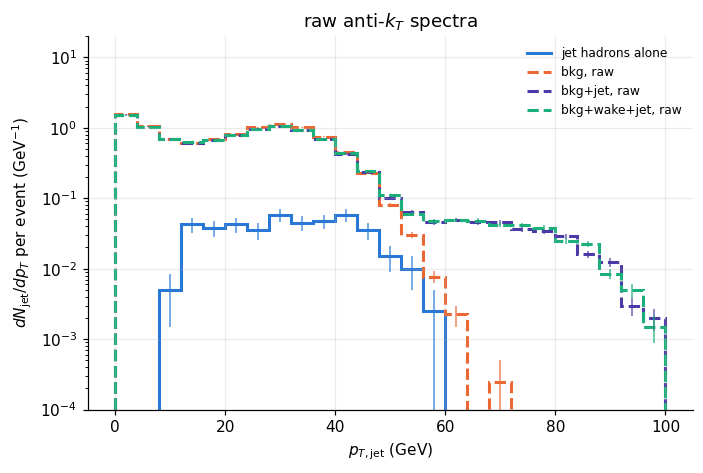

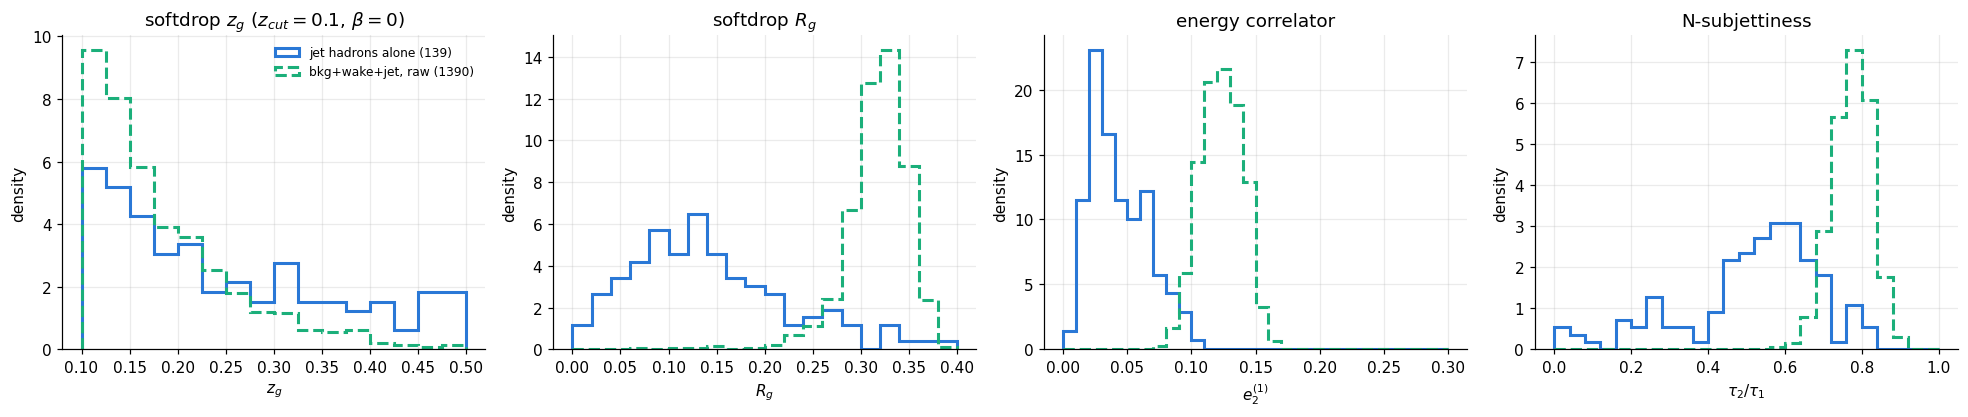

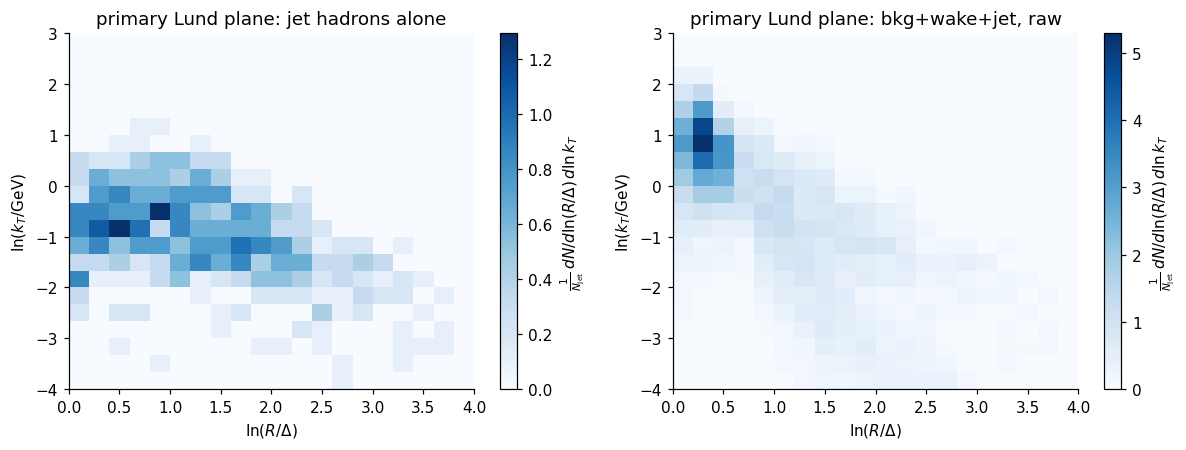

jet          : <z_g> 0.175, <R_g> 0.076, <m_sd> 2.1 GeV, <e2> 0.044, <tau21> 0.516, primary declusterings per jet 4.0
bkg+wake+jet : <z_g> 0.182, <R_g> 0.316, <m_sd> 13.2 GeV, <e2> 0.123, <tau21> 0.773, primary declusterings per jet 9.1


In [8]:
t0 = time.time()
RAW = {}
for leg, arr in LEGS_REAL.items():
    cs = fastjet.ClusterSequence(arr, JET_DEF)
    jets, idx = sorted_jets(cs, 1.0)
    keep = abs(jets.rapidity) < JET_ETA
    RAW[leg] = {"jets": jets[keep], "idx": idx[keep]}
t_raw = time.time() - t0
print(f"{len(LEGS)} x {len(AU_EVENT)} AuAu samples clustered in {t_raw:.1f} s "
      f"({t_raw / (len(LEGS) * len(AU_EVENT)) * 1e3:.1f} ms per event)")


def match(leg_jets, leg_cons):
    # for every jet of the jet hadrons alone (per AuAu sample): the nearest AuAu jet
    ref = FJ[AU_FRAG]
    aj = ak.zip({"px": leg_jets.px, "py": leg_jets.py, "pz": leg_jets.pz, "E": leg_jets.E,
                 "frag_pt": ak.sum(leg_cons.pt * (leg_cons.origin == 1), axis=-1)}, with_name="Momentum4D")
    pairs = ak.cartesian({"f": ref, "a": aj}, nested=True)
    dr = pairs.f.deltaR(pairs.a)
    best = ak.argmin(dr, axis=2, keepdims=True)
    return {"ref": ref, "jet": ak.flatten(pairs.a[best], axis=2), "dR": ak.flatten(dr[best], axis=2),
            "best": ak.flatten(best, axis=2)}


for leg in LEGS[1:]:
    RAW[leg]["cons"] = gather(LEGS_REAL[leg], RAW[leg]["idx"])
    RAW[leg]["match"] = match(RAW[leg]["jets"], RAW[leg]["cons"])
    m = RAW[leg]["match"]
    share = ak.flatten(m["jet"].frag_pt / m["ref"].pt).to_numpy()
    print(f"{leg:13s}: {len(share)} jets matched, median dR {np.median(ak.to_numpy(ak.fill_none(ak.flatten(m['dR']), np.nan))):.3f}, "
          f"{np.mean(share > 0.5):.1%} carry > 50% of the jet's pT from its hadrons; "
          f"raw pT - pT alone = {ak.mean(m['jet'].pt - m['ref'].pt):+.1f} GeV")

fig, ax = plt.subplots(figsize=(6.5, 4.4))
PT_RAW = np.arange(0, 104, 4.0)
h, err = per_sample_hist(fj_pt, fj_ev, PT_RAW, N_FRAG)
step(ax, PT_RAW, h, err, "jet hadrons alone", COL["jet"])
for leg in LEGS:
    J = RAW[leg]["jets"]
    h, err = per_sample_hist(ak.flatten(J.pt).to_numpy(), per_jet(AU_EVENT, J), PT_RAW, N_OVER)
    step(ax, PT_RAW, h, err, f"{leg}, raw", COL[leg], ls="--")
ax.set(yscale="log", ylim=(1e-4, 20), xlabel=r"$p_{T,\mathrm{jet}}$ (GeV)",
       ylabel=r"$dN_\mathrm{jet}/dp_T$ per event (GeV$^{-1}$)", title="raw anti-$k_T$ spectra")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# substructure of the matched AuAu jets (hard reference jets), no subtraction
leg = "bkg+wake+jet"
m = RAW[leg]["match"]
sel = m["ref"].pt > SUB_PT_MIN
best = m["best"][sel]
matched_cons = ak.flatten(gather(LEGS_REAL[leg], RAW[leg]["idx"][best]), axis=1)
SUB[leg] = substructure(matched_cons)

fig, axs = plt.subplots(1, 4, figsize=(18, 3.9))
for key, ax, bins, xl in (("zg", axs[0], np.linspace(0.1, 0.5, 17), r"$z_g$"),
                          ("rg", axs[1], np.linspace(0, 0.4, 21), r"$R_g$"),
                          ("e2", axs[2], np.linspace(0, 0.3, 31), r"$e_2^{(1)}$"),
                          ("tau21", axs[3], np.linspace(0, 1, 26), r"$\tau_2/\tau_1$")):
    for name, ls in (("jet", "-"), (leg, "--")):
        x = SUB[name][key]
        x = x[np.isfinite(x)]
        ax.hist(x, bins, density=True, histtype="step", lw=2, ls=ls, color=COL[name],
                label=("jet hadrons alone" if name == "jet" else f"{name}, raw") + f" ({len(x)})")
    ax.set(xlabel=xl, ylabel="density")
axs[0].set_title("softdrop $z_g$ ($z_{cut}=0.1$, $\\beta=0$)"); axs[1].set_title("softdrop $R_g$")
axs[2].set_title("energy correlator"); axs[3].set_title("N-subjettiness")
axs[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
LX, LY = np.linspace(0, 4, 21), np.linspace(-4, 3, 22)
for ax, name in zip(axs, ("jet", leg)):
    lund = SUB[name]["lund"]
    lx = ak.flatten(np.log(R / lund.Delta)).to_numpy()
    ly = ak.flatten(np.log(lund.kt)).to_numpy()
    h = np.histogram2d(lx, ly, (LX, LY))[0] / len(lund) / np.diff(LX)[0] / np.diff(LY)[0]
    im = ax.pcolormesh(LX, LY, h.T, cmap="Blues", vmin=0)
    plt.colorbar(im, ax=ax, label=r"$\frac{1}{N_\mathrm{jet}}\,dN/d\ln(R/\Delta)\,d\ln k_T$")
    ax.set(xlabel=r"$\ln(R/\Delta)$", ylabel=r"$\ln(k_T/\mathrm{GeV})$", xlim=(0, 4),
           title=f"primary Lund plane: {'jet hadrons alone' if name == 'jet' else name + ', raw'}")
    ax.grid(False)
plt.tight_layout(); plt.show()
for name in ("jet", leg):
    s = SUB[name]
    print(f"{name:13s}: <z_g> {np.nanmean(s['zg']):.3f}, <R_g> {np.nanmean(s['rg']):.3f}, <m_sd> "
          f"{np.nanmean(s['msd']):.1f} GeV, <e2> {np.nanmean(s['e2']):.3f}, <tau21> {np.nanmean(s['tau21']):.3f}, "
          f"primary declusterings per jet {ak.mean(ak.num(s['lund'])):.1f}")

## 6. Jet area and $\rho$ with explicit ghosts added by hand

The array interface has no areas, but an active area with explicit ghosts is only clustering with extra,
infinitely soft particles: each ghost carries an area, and a jet's area is the number of ghosts it
contains times the ghost area. The ghosts below are laid out the way FastJet's
`GhostedAreaSpec(1.5, 1, 0.005)` does: a grid of $2 n_y \times n_\varphi$ cells, $n_y = \mathrm{int}(y_\mathrm{max}/\sqrt{a} + 0.5)$,
$n_\varphi = \mathrm{int}(2\pi/\sqrt{a} + 0.5)$, one ghost per cell, displaced uniformly within its cell
(grid scatter 1), $p_T = 10^{-100}(1 \pm 0.05)$ GeV. They get `origin = -1`, so `constituent_index` finds
them. Then everything is awkward arithmetic:

* area $A$ = (number of ghost constituents) $\times$ ghost area;
* $\rho$ = median over the $k_T$ jets in $|\eta| < 1.1$, after dropping the two hardest (`[:, 2:]` on the
  $p_T$-sorted, $\eta$-selected jets), of $p_T/A$; ghost-only jets enter with $p_T/A \approx 0$, as the empty
  jets of FastJet's estimator;
* random cones: one per background sample, a broadcast of the cone axis against the particles.

The events go through in chunks of `CHUNK` samples (the ghosts triple the array).

In [9]:
def ghost_grid(ymax=ETA_MAX, area=GHOST_AREA):
    d = np.sqrt(area)
    ny, nphi = int(ymax / d + 0.5), int(2 * np.pi / d + 0.5)
    dy, dphi = ymax / ny, 2 * np.pi / nphi
    iy, ip = np.meshgrid(np.arange(-ny, ny), np.arange(nphi), indexing="ij")
    return (iy.ravel() + 0.5) * dy, (ip.ravel() + 0.5) * dphi, dy, dphi


GY, GPHI, DY, DPHI = ghost_grid()
GA = DY * DPHI
N_GHOST = len(GY)
print(f"{N_GHOST} ghosts per event of area {GA:.8f} (FastJet GhostedAreaSpec(1.5, 1, 0.005): "
      f"{fastjet.GhostedAreaSpec(ETA_MAX, 1, GHOST_AREA).actual_ghost_area():.8f})")


def ghosts(n_events):
    shape = (n_events, N_GHOST)
    y = GY + (RNG.random(shape) - 0.5) * DY
    phi = GPHI + (RNG.random(shape) - 0.5) * DPHI
    pt = 1e-100 * (1 + 0.1 * (RNG.random(shape) - 0.5))
    rec = ak.zip({"px": (pt * np.cos(phi)).ravel(), "py": (pt * np.sin(phi)).ravel(),
                  "pz": (pt * np.sinh(y)).ravel(), "E": (pt * np.cosh(y)).ravel(),
                  "pid": np.zeros(pt.size, np.int32), "charged": np.zeros(pt.size, bool),
                  "origin": np.full(pt.size, -1, np.int8)}, with_name="Momentum4D")
    return ak.unflatten(rec, np.full(n_events, N_GHOST))


def ak_median(x):
    # median along axis 1 (numpy convention: mean of the two middle values)
    s = ak.sort(x, axis=1)
    n = ak.num(s)
    i = ak.local_index(s)
    lo = ak.firsts(s[i == (n - 1) // 2])
    hi = ak.firsts(s[i == n // 2])
    return ak.to_numpy(ak.fill_none((lo + hi) / 2, np.nan))


def ghosted(parts):
    # anti-kT jets with areas, rho (2 hardest kT jets out, and none out) for one chunk of events
    wg = ak.to_packed(ak.concatenate([parts, ghosts(len(parts))], axis=1))
    cs = fastjet.ClusterSequence(wg, JET_DEF)
    jets, idx = sorted_jets(cs, 1.0)
    cons = gather(wg, idx)
    area = ak.sum(cons.origin == -1, axis=-1) * GA
    frag_pt = ak.sum(cons.pt * (cons.origin == 1), axis=-1)
    csk = fastjet.ClusterSequence(wg, BKG_DEF)
    kt, kidx = sorted_jets(csk)
    kcons = gather(wg, kidx)
    karea = ak.sum(kcons.origin == -1, axis=-1) * GA
    in_acc = abs(kt.rapidity) < BKG_ETA
    dens = (kt.pt / karea)[in_acc]
    total_area = ak.to_numpy(ak.sum(karea, axis=1))
    keep = abs(jets.rapidity) < JET_ETA
    return {"jets": jets[keep], "area": area[keep], "frag_pt": frag_pt[keep],
            "rho": ak_median(dens[:, N_EXCL:]), "rho0": ak_median(dens),
            "total_area": total_area, "n_kt": ak.to_numpy(ak.num(dens))}


t0 = time.time()
GH = {}
for leg, arr in LEGS_REAL.items():
    parts = [ghosted(arr[a:a + CHUNK]) for a in range(0, len(arr), CHUNK)]
    GH[leg] = {k: (ak.concatenate([p[k] for p in parts]) if isinstance(parts[0][k], ak.Array)
                   else np.concatenate([p[k] for p in parts])) for k in parts[0]}
t_gh = time.time() - t0
print(f"{len(LEGS)} x {len(AU_EVENT)} AuAu samples with {N_GHOST} ghosts each: {t_gh:.1f} s")
ACC_AREA = 2 * ETA_MAX * 2 * np.pi
A0 = np.pi * R ** 2
for leg in LEGS:
    g = GH[leg]
    print(f"{leg:13s}: sum of kT jet areas / acceptance {g['total_area'].min() / ACC_AREA:.5f} .. "
          f"{g['total_area'].max() / ACC_AREA:.5f};  rho {np.mean(g['rho']):.2f} +- {np.std(g['rho']):.2f} GeV "
          f"(none out {np.mean(g['rho0']):.2f}), {np.mean(g['n_kt']):.1f} kT jets in |eta| < {BKG_ETA:.1f}")

3738 ghosts per event of area 0.00504268 (FastJet GhostedAreaSpec(1.5, 1, 0.005): 0.00504268)


3 x 1000 AuAu samples with 3738 ghosts each: 35.9 s
bkg          : sum of kT jet areas / acceptance 1.00000 .. 1.00000;  rho 63.19 +- 7.08 GeV (none out 63.69), 43.1 kT jets in |eta| < 1.1
bkg+jet      : sum of kT jet areas / acceptance 1.00000 .. 1.00000;  rho 64.09 +- 7.28 GeV (none out 64.81), 42.8 kT jets in |eta| < 1.1
bkg+wake+jet : sum of kT jet areas / acceptance 1.00000 .. 1.00000;  rho 64.46 +- 7.24 GeV (none out 65.23), 42.8 kT jets in |eta| < 1.1


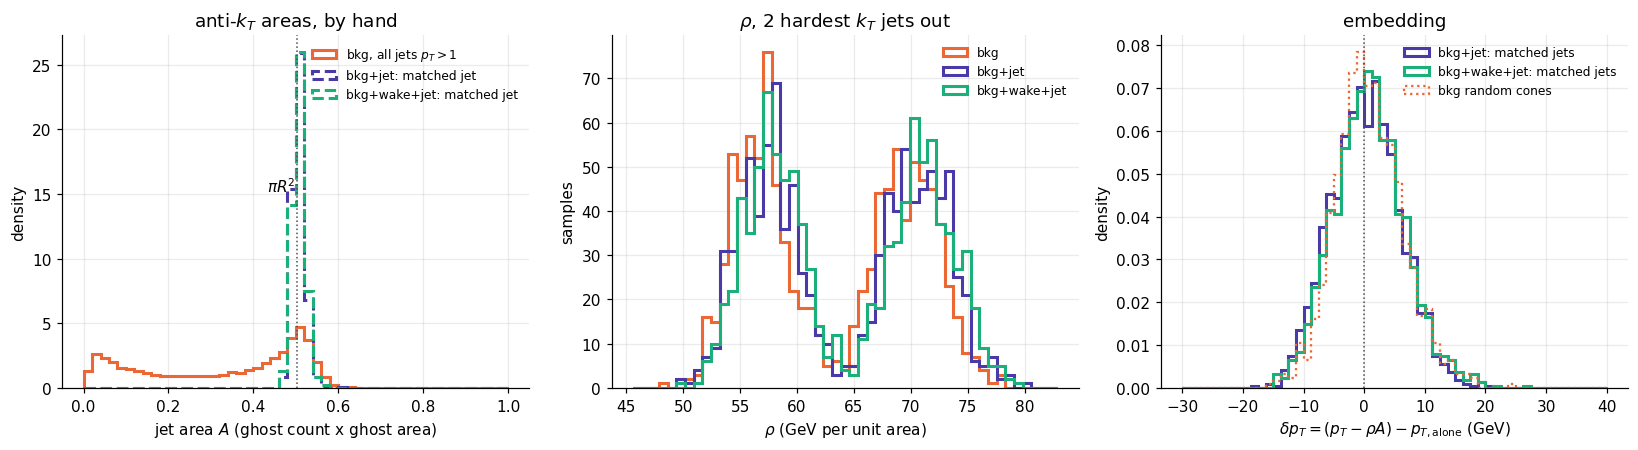

bkg+jet      : 1730 of 1730 jets matched (> 50% of their pT); <A>/piR^2 1.012; delta pT +0.26 +- 0.14 GeV, sigma 5.74; rho - rho(bkg) +0.90 GeV
bkg+wake+jet : 1730 of 1730 jets matched (> 50% of their pT); <A>/piR^2 1.012; delta pT +0.81 +- 0.14 GeV, sigma 5.85; rho - rho(bkg) +1.28 GeV
random cones: <delta pT> +0.95 +- 0.18 GeV, sigma 5.56 GeV


In [10]:
# areas of the matched jets, rho of the paired samples, random cones, embedding
for leg in LEGS[1:]:
    g = GH[leg]
    aj = ak.zip({"px": g["jets"].px, "py": g["jets"].py, "pz": g["jets"].pz, "E": g["jets"].E,
                 "area": g["area"], "frag_pt": g["frag_pt"]}, with_name="Momentum4D")
    ref = FJ[AU_FRAG]
    pairs = ak.cartesian({"f": ref, "a": aj}, nested=True)
    best = ak.argmin(pairs.f.deltaR(pairs.a), axis=2, keepdims=True)
    mj = ak.flatten(pairs.a[best], axis=2)
    rho_j = ak.broadcast_arrays(ak.Array(g["rho"]), mj.pt)[0]
    ok = mj.frag_pt / ref.pt > 0.5
    g["match"] = {"pt_ref": ak.flatten(ref.pt[ok]).to_numpy(), "area": ak.flatten(mj.area[ok]).to_numpy(),
                  "dpt": ak.flatten((mj.pt - rho_j * mj.area - ref.pt)[ok]).to_numpy(),
                  "n": int(ak.sum(ak.num(ref))), "n_ok": int(ak.sum(ok))}

bkg = LEGS_REAL["bkg"]
eta_c = RNG.uniform(-JET_ETA, JET_ETA, len(bkg))
phi_c = RNG.uniform(-np.pi, np.pi, len(bkg))
dphi = (bkg.phi - phi_c + np.pi) % (2 * np.pi) - np.pi
in_cone = (bkg.eta - eta_c) ** 2 + dphi ** 2 < R ** 2
RC_DPT = ak.to_numpy(ak.sum(bkg.pt[in_cone], axis=1)) - GH["bkg"]["rho"] * A0

fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axs[0]
A_BINS = np.linspace(0, 1.0, 51)
g = GH["bkg"]
ax.hist(ak.flatten(g["area"]).to_numpy(), A_BINS, density=True, histtype="step", lw=2, color=COL["bkg"],
        label=r"bkg, all jets $p_T > 1$")
for leg in LEGS[1:]:
    ax.hist(GH[leg]["match"]["area"], A_BINS, density=True, histtype="step", lw=2, ls="--", color=COL[leg],
            label=f"{leg}: matched jet")
ax.axvline(A0, color="0.3", lw=1, ls=":"); ax.text(A0, ax.get_ylim()[1] * 0.6, r"$\pi R^2$ ", ha="right", va="top")
ax.set(xlabel="jet area $A$ (ghost count x ghost area)", ylabel="density", title="anti-$k_T$ areas, by hand")
ax.legend(fontsize=8, loc="upper right")

ax = axs[1]
bins = np.linspace(min(GH[l]["rho"].min() for l in LEGS) - 3, max(GH[l]["rho"].max() for l in LEGS) + 3, 50)
for leg in LEGS:
    ax.hist(GH[leg]["rho"], bins, histtype="step", lw=2, color=COL[leg], label=leg)
ax.set(xlabel=r"$\rho$ (GeV per unit area)", ylabel="samples", title=r"$\rho$, 2 hardest $k_T$ jets out")
ax.legend(fontsize=8)

ax = axs[2]
bins = np.linspace(-30, 40, 57)
for leg in LEGS[1:]:
    ax.hist(GH[leg]["match"]["dpt"], bins, density=True, histtype="step", lw=2, color=COL[leg],
            label=f"{leg}: matched jets")
ax.hist(RC_DPT, bins, density=True, histtype="step", lw=1.5, ls=":", color=COL["bkg"], label="bkg random cones")
ax.axvline(0, color="0.3", lw=1, ls=":")
ax.set(xlabel=r"$\delta p_T = (p_T - \rho A) - p_{T,\mathrm{alone}}$ (GeV)", ylabel="density", title="embedding")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for leg in LEGS[1:]:
    mm = GH[leg]["match"]
    d = mm["dpt"]
    print(f"{leg:13s}: {mm['n_ok']} of {mm['n']} jets matched (> 50% of their pT); <A>/piR^2 {mm['area'].mean() / A0:.3f}; "
          f"delta pT {d.mean():+.2f} +- {d.std() / np.sqrt(len(d)):.2f} GeV, sigma {d.std():.2f}; "
          f"rho - rho(bkg) {np.mean(GH[leg]['rho'] - GH['bkg']['rho']):+.2f} GeV")
print(f"random cones: <delta pT> {RC_DPT.mean():+.2f} +- {RC_DPT.std() / np.sqrt(len(RC_DPT)):.2f} GeV, "
      f"sigma {RC_DPT.std():.2f} GeV")

### The subtracted spectrum, and the classic interface on the same samples

$p_T - \rho A$ with the hand-made areas, against the raw spectrum (section 5) and the jets alone. The last
cell repeats the ghosted clustering of a few samples with the classic `ClusterSequenceArea` +
`JetMedianBackgroundEstimator`. The ghosts differ (random), so single values differ by the ghost jitter
(the kT median moves by $\sim 1.7$ GeV per event from new ghosts alone, see `jet_fastjet.ipynb`); the means
must agree. The estimator is set to scalar areas (`set_use_area_4vector(False)`), which is what the ghost
count measures; with FastJet 3's default 4-vector area its $\rho$ is $\approx 1$ GeV larger.

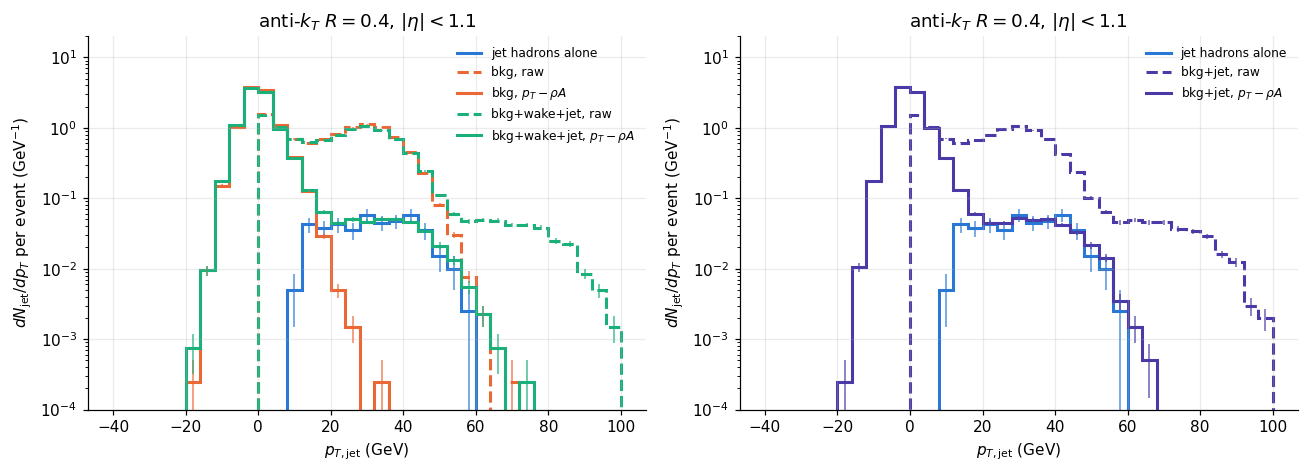

In [11]:
PT_E = np.arange(-40, 104, 4.0)
fig, axs = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, legs in ((axs[0], ("bkg", "bkg+wake+jet")), (axs[1], ("bkg+jet",))):
    h, err = per_sample_hist(fj_pt, fj_ev, PT_E, N_FRAG)
    step(ax, PT_E, h, err, "jet hadrons alone", COL["jet"])
    for leg in legs:
        g = GH[leg]
        ev = per_jet(AU_EVENT, g["jets"])
        h, err = per_sample_hist(ak.flatten(g["jets"].pt).to_numpy(), ev, PT_E, N_OVER)
        step(ax, PT_E, h, err, f"{leg}, raw", COL[leg], ls="--")
        rho_j = ak.broadcast_arrays(ak.Array(g["rho"]), g["jets"].pt)[0]
        sub = ak.flatten(g["jets"].pt - rho_j * g["area"]).to_numpy()
        h, err = per_sample_hist(sub, ev, PT_E, N_OVER)
        step(ax, PT_E, h, err, rf"{leg}, $p_T - \rho A$", COL[leg])
    ax.set(yscale="log", ylim=(1e-4, 20), xlabel=r"$p_{T,\mathrm{jet}}$ (GeV)",
           ylabel=r"$dN_\mathrm{jet}/dp_T$ per event (GeV$^{-1}$)", title=rf"anti-$k_T$ $R={R}$, $|\eta|<{JET_ETA:.1f}$")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [12]:
# classic interface on the first N_CHECK bkg+jet samples: same particles, own ghosts
N_CHECK = min(100, len(AU_EVENT))
ad = fastjet.AreaDefinition(fastjet.active_area_explicit_ghosts, fastjet.GhostedAreaSpec(ETA_MAX, 1, GHOST_AREA))
sel = (~fastjet.SelectorNHardest(N_EXCL)) * fastjet.SelectorAbsRapMax(BKG_ETA)
rho_cl, a_cl = [], []
t0 = time.time()
arr = LEGS_REAL["bkg+jet"]
for i in range(N_CHECK):
    ev = arr[i]
    parts = [fastjet.PseudoJet(float(px), float(py), float(pz), float(E))
             for px, py, pz, E in zip(ev.px, ev.py, ev.pz, ev.E)]
    csk = fastjet.ClusterSequenceArea(parts, BKG_DEF, ad)
    est = fastjet.JetMedianBackgroundEstimator(sel, BKG_DEF, ad)
    est.set_use_area_4vector(False)          # scalar areas, as the ghost count above
    est.set_jets(csk.inclusive_jets())
    rho_cl.append(est.rho())
    cs = fastjet.ClusterSequenceArea(parts, JET_DEF, ad)
    a_cl += [j.area() for j in fastjet.sorted_by_pt(cs.inclusive_jets(1.0))[:2]]
t_cl = time.time() - t0
rho_cl = np.array(rho_cl)
rho_ak = GH["bkg+jet"]["rho"][:N_CHECK]
a_ak = ak.flatten(GH["bkg+jet"]["area"][:N_CHECK, :2]).to_numpy()
d = rho_ak - rho_cl
print(f"{N_CHECK} bkg+jet samples, classic ClusterSequenceArea vs ghosts by hand:")
print(f"  rho: classic {rho_cl.mean():.2f}, array {rho_ak.mean():.2f} GeV; per sample difference "
      f"{d.mean():+.2f} +- {d.std() / np.sqrt(len(d)):.2f}, rms {d.std():.2f} (ghost jitter)")
print(f"  <A>/piR^2 of the two leading jets: classic {np.mean(a_cl) / A0:.3f}, array {a_ak.mean() / A0:.3f}")
print(f"  time for these samples: classic loop {t_cl:.1f} s, array (all {len(AU_EVENT)} samples of this leg) "
      f"{t_gh / len(LEGS):.1f} s")

100 bkg+jet samples, classic ClusterSequenceArea vs ghosts by hand:
  rho: classic 57.52, array 57.57 GeV; per sample difference +0.06 +- 0.15, rms 1.52 (ghost jitter)
  <A>/piR^2 of the two leading jets: classic 1.031, array 1.027
  time for these samples: classic loop 1.8 s, array (all 1000 samples of this leg) 12.0 s


## 7. Summary

In [13]:
mm, mw = GH["bkg+jet"]["match"], GH["bkg+wake+jet"]["match"]
rows = [
    ("events x samples (jet hadrons / AuAu)", f"{len(EVENTS)} x {len(FRAG) // len(EVENTS)} / {len(EVENTS)} x {len(AU_EVENT) // len(EVENTS)}"),
    ("jets alone: array == classic interface", f"max |dpT| = {diff:.1e} GeV"),
    ("anti-kT, AuAu, no ghosts", f"{t_raw / (len(LEGS) * len(AU_EVENT)) * 1e3:.1f} ms per event"),
    ("sum of kT areas / acceptance", f"{min(GH[l]['total_area'].min() for l in LEGS) / ACC_AREA:.5f} .. "
                                    f"{max(GH[l]['total_area'].max() for l in LEGS) / ACC_AREA:.5f}"),
    ("<A>/piR^2, matched jets (bkg+jet)", f"{mm['area'].mean() / A0:.3f}"),
    ("rho bkg, 2 out / none out", f"{GH['bkg']['rho'].mean():.1f} / {GH['bkg']['rho0'].mean():.1f} GeV"),
    ("rho, array - classic (100 samples)", f"{d.mean():+.2f} +- {d.std() / np.sqrt(len(d)):.2f} GeV"),
    ("random cone <dpT>, sigma", f"{RC_DPT.mean():+.2f}, {RC_DPT.std():.2f} GeV"),
    ("embedding <dpT>, sigma (bkg+jet)", f"{mm['dpt'].mean():+.2f} +- {mm['dpt'].std() / np.sqrt(len(mm['dpt'])):.2f}, {mm['dpt'].std():.2f} GeV"),
    ("embedding <dpT>, sigma (bkg+wake+jet)", f"{mw['dpt'].mean():+.2f} +- {mw['dpt'].std() / np.sqrt(len(mw['dpt'])):.2f}, {mw['dpt'].std():.2f} GeV"),
    ("<z_g> alone / AuAu raw", f"{np.nanmean(SUB['jet']['zg']):.3f} / {np.nanmean(SUB['bkg+wake+jet']['zg']):.3f}"),
]
w = max(len(a) for a, _ in rows)
for a, b_ in rows:
    print(f"{a:{w}s}  {b_}")

events x samples (jet hadrons / AuAu)   2 x 50 / 2 x 500
jets alone: array == classic interface  max |dpT| = 7.1e-15 GeV
anti-kT, AuAu, no ghosts                1.6 ms per event
sum of kT areas / acceptance            1.00000 .. 1.00000
<A>/piR^2, matched jets (bkg+jet)       1.012
rho bkg, 2 out / none out               63.2 / 63.7 GeV
rho, array - classic (100 samples)      +0.06 +- 0.15 GeV
random cone <dpT>, sigma                +0.95, 5.56 GeV
embedding <dpT>, sigma (bkg+jet)        +0.26 +- 0.14, 5.74 GeV
embedding <dpT>, sigma (bkg+wake+jet)   +0.81 +- 0.14, 5.85 GeV
<z_g> alone / AuAu raw                  0.175 / 0.182
